# Consolidador Automático de Relatórios — Demonstração

Este notebook roda o projeto **passo a passo** para mostrar que cada fase funciona:
leitura → limpeza → consolidação → relatório Excel → PDF executivo.

> Rode as células em ordem (menu **Run > Run All**).

## 0. Imports

In [1]:
from pathlib import Path

from consolidador.consolidacao import consolidar
from consolidador.leitor import ler_pasta
from consolidador.limpeza import limpar_dataframe
from consolidador.relatorio import gerar_relatorio_excel, resumo_por_mes, resumo_por_produto
from consolidador.resumo_pdf import calcular_kpis, gerar_resumo_pdf

ENTRADA = Path("dados_exemplo")
SAIDA = Path("saida")
print("Imports OK")

Imports OK


## 1. Leitura — o que entra (dados CRUS e bagunçados)

Repare nos nomes de coluna inconsistentes e nos valores em texto/formato misturado.

In [2]:
planilhas = ler_pasta(ENTRADA)
print(f"{len(planilhas)} tabelas lidas:\n")
for p in planilhas:
    print(f"- {p.origem:<32} colunas={list(p.df.columns)}")

6 tabelas lidas:

- vendas_abril.xlsx[Vendas]        colunas=['Data', 'Produto', 'Quantidade', 'Preco']
- vendas_abril.xlsx[Rascunho]      colunas=['obs']
- vendas_fevereiro.xlsx[Sheet1]    colunas=['DT', 'produto ', 'quantidade', 'valor']
- vendas_janeiro.xlsx[Sheet1]      colunas=['Data da Venda', 'Produto', 'Qtd', 'Valor Total']
- vendas_maio.xlsx[Sheet1]         colunas=['Data', 'Produto', 'Quantidade', 'Preço Unitário', 'Região']
- vendas_marco.csv                 colunas=['data', 'produto', 'qtd', 'valor total']


In [3]:
# Exemplo de bagunça: janeiro tem 'Valor Total' como TEXTO no padrão BR (1.200,50)
planilhas[2].df.head()

,DT,produto,quantidade,valor
0,2025-02-03 00:00:00,CAFÉ 500G,12,1096.4
1,2025-02-18 00:00:00,CAFÉ 500G,6,253.47
2,2025-02-10 00:00:00,AÇÚCAR 1KG,12,575.39
3,2025-02-27 00:00:00,FARINHA DE TRIGO,12,1484.39
4,2025-02-21 00:00:00,CAFÉ 500G,7,963.6


## 2. Limpeza — antes x depois de uma planilha

In [4]:
crua = planilhas[2].df
limpa = limpar_dataframe(crua)
print("ANTES (cru):", list(crua.columns))
print("DEPOIS (limpo):", list(limpa.columns), "| dtypes:", dict(limpa.dtypes.astype(str)))
limpa.head()

ANTES (cru): ['DT', 'produto ', 'quantidade', 'valor']
DEPOIS (limpo): ['data', 'produto', 'quantidade', 'valor'] | dtypes: {'data': 'datetime64[us]', 'produto': 'str', 'quantidade': 'float64', 'valor': 'float64'}


,data,produto,quantidade,valor
0,2025-02-03,Café 500G,12.0,1096.40
1,2025-02-18,Café 500G,6.0,253.47
2,2025-02-10,Açúcar 1Kg,12.0,575.39
3,2025-02-27,Farinha De Trigo,12.0,1484.39
4,2025-02-21,Café 500G,7.0,963.60


## 3. Consolidação — tudo num único DataFrame

In [5]:
resultado = consolidar(planilhas)
df = resultado.dados
print(f"{len(df)} registros consolidados de {df['origem'].nunique()} fontes")
print("Descartadas (sem dados de venda):", resultado.descartadas)
df.head()

52 registros consolidados de 5 fontes
Descartadas (sem dados de venda): ['vendas_abril.xlsx[Rascunho]']


,data,produto,quantidade,valor,regiao,origem
0,2025-04-28,Farinha De Trigo,6.0,1146.14,NaN,vendas_abril.xlsx[Vendas]
1,2025-04-01,Café 500G,17.0,813.67,NaN,vendas_abril.xlsx[Vendas]
2,2025-04-22,Farinha De Trigo,4.0,1170.15,NaN,vendas_abril.xlsx[Vendas]
3,2025-04-24,Arroz 5Kg,10.0,800.23,NaN,vendas_abril.xlsx[Vendas]
4,2025-04-04,Açúcar 1Kg,17.0,10.85,NaN,vendas_abril.xlsx[Vendas]


In [6]:
df["origem"].value_counts().sort_index()

origem
vendas_abril.xlsx[Vendas]         9
vendas_fevereiro.xlsx[Sheet1]    10
vendas_janeiro.xlsx[Sheet1]      12
vendas_maio.xlsx[Sheet1]         10
vendas_marco.csv                 11
Name: count, dtype: int64

## 4. Resumos e KPIs

In [7]:
resumo_por_produto(df)

,produto,faturamento,ticket_medio,quantidade_total,num_vendas
2,Café 500G,8258.48,635.267692,144.0,13
3,Farinha De Trigo,7831.68,1118.811429,61.0,7
0,Arroz 5Kg,7523.70,752.370000,158.0,10
4,Feijão 1Kg,6198.99,516.582500,155.0,12
1,Açúcar 1Kg,3904.17,433.796667,94.0,9


In [8]:
resumo_por_mes(df)

,mes,faturamento,num_vendas
0,2025-01,6461.84,12
1,2025-02,9026.56,10
2,2025-03,6817.42,10
3,2025-04,7186.71,9
4,2025-05,4224.49,10


In [9]:
calcular_kpis(df)

{'Faturamento total': 'R$ 33.717,02',
 'Nº de vendas': '51',
 'Ticket médio': 'R$ 661,12',
 'Produto campeão': 'Café 500G'}

## 5. Gráfico inline (faturamento por produto)

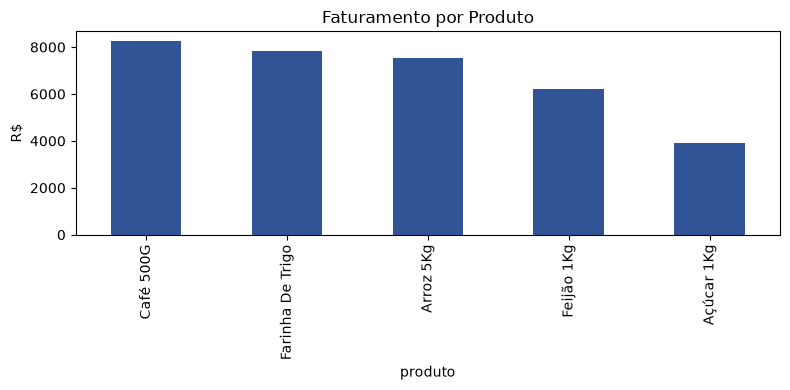

In [10]:
import matplotlib.pyplot as plt

rp = resumo_por_produto(df)
ax = rp.plot.bar(x="produto", y="faturamento", legend=False, color="#305496", figsize=(8, 4))
ax.set_ylabel("R$")
ax.set_title("Faturamento por Produto")
plt.tight_layout()
plt.show()

## 6. Gerar os arquivos finais (Excel + PDF)

In [11]:
caminho_excel = gerar_relatorio_excel(df, SAIDA / "relatorio_consolidado.xlsx")
caminho_pdf = gerar_resumo_pdf(df, SAIDA / "resumo_executivo.pdf")
print("Excel gerado:", caminho_excel, "->", caminho_excel.exists())
print("PDF gerado:  ", caminho_pdf, "->", caminho_pdf.exists())

Excel gerado: saida/relatorio_consolidado.xlsx -> True
PDF gerado:   saida/resumo_executivo.pdf -> True


✅ Se todas as células rodaram sem erro e os dois arquivos foram gerados em `saida/`, **o projeto está funcionando de ponta a ponta**.